In [9]:
import pandas as pd
df=pd.read_csv("C:/Users/Suganth/Downloads/kaggle.csv.zip")

In [11]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [23]:
#EXPLORATORY DATA ANALYSIS
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [31]:
#CATEGORICAL VARIABLE
df['Loan_ID'].nunique()

614

In [33]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

<Axes: xlabel='Loan_Status'>

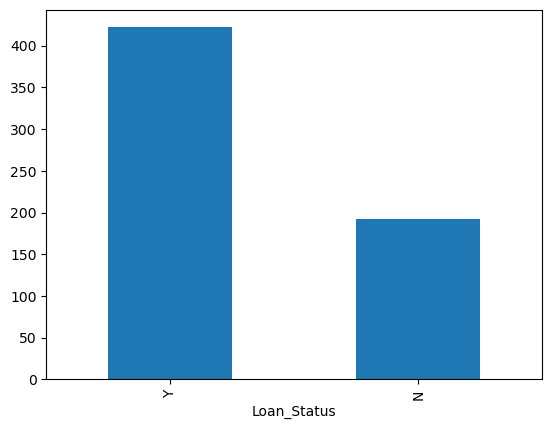

In [35]:
df['Loan_Status'].value_counts().plot(kind='bar')

In [45]:
df['Loan_Status'].value_counts(dropna=False,normalize=True).map("{:.2%}".format)

Loan_Status
Y    68.73%
N    31.27%
Name: proportion, dtype: object

In [55]:
categorical_cols=df.select_dtypes(include='O').columns.to_list()
print(categorical_cols)

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [57]:
categorical_cols.remove('Loan_ID')

In [65]:
df['Loan_Amount_Term'].dropna().unique()

array([360., 120., 240., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [73]:
categorical_cols= categorical_cols+['Loan_Amount_Term']

In [79]:
df['Credit_History'].unique()

array([ 1.,  0., nan])

In [81]:
 categorical_cols= categorical_cols +['Credit_History']

In [83]:
print(categorical_cols)

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status', 'Loan_Amount_Term', 'Credit_History']


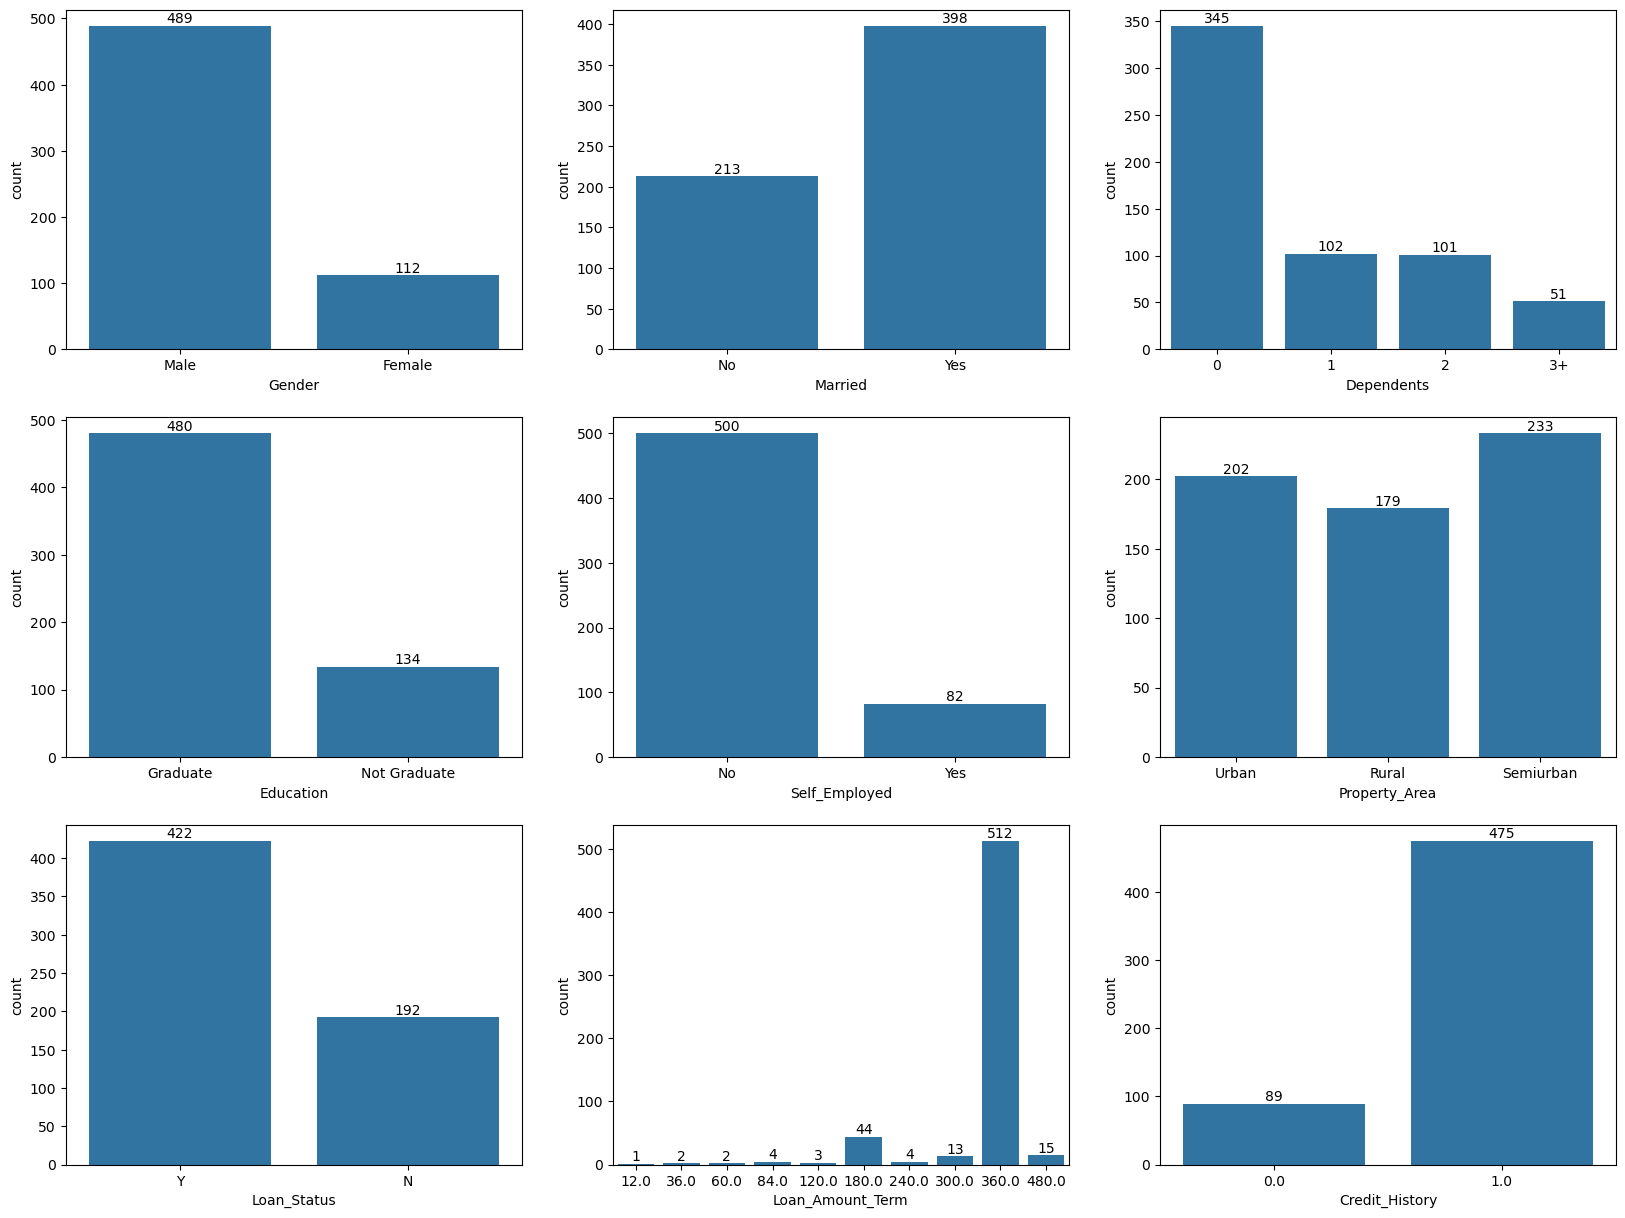

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
fig,axes = plt.subplots(3,3,figsize=(20,15))
for col, subplot in zip(categorical_cols,axes.flatten()):
    sns.countplot(x=df[col],ax=subplot).bar_label(subplot.containers[0])
plt.show()

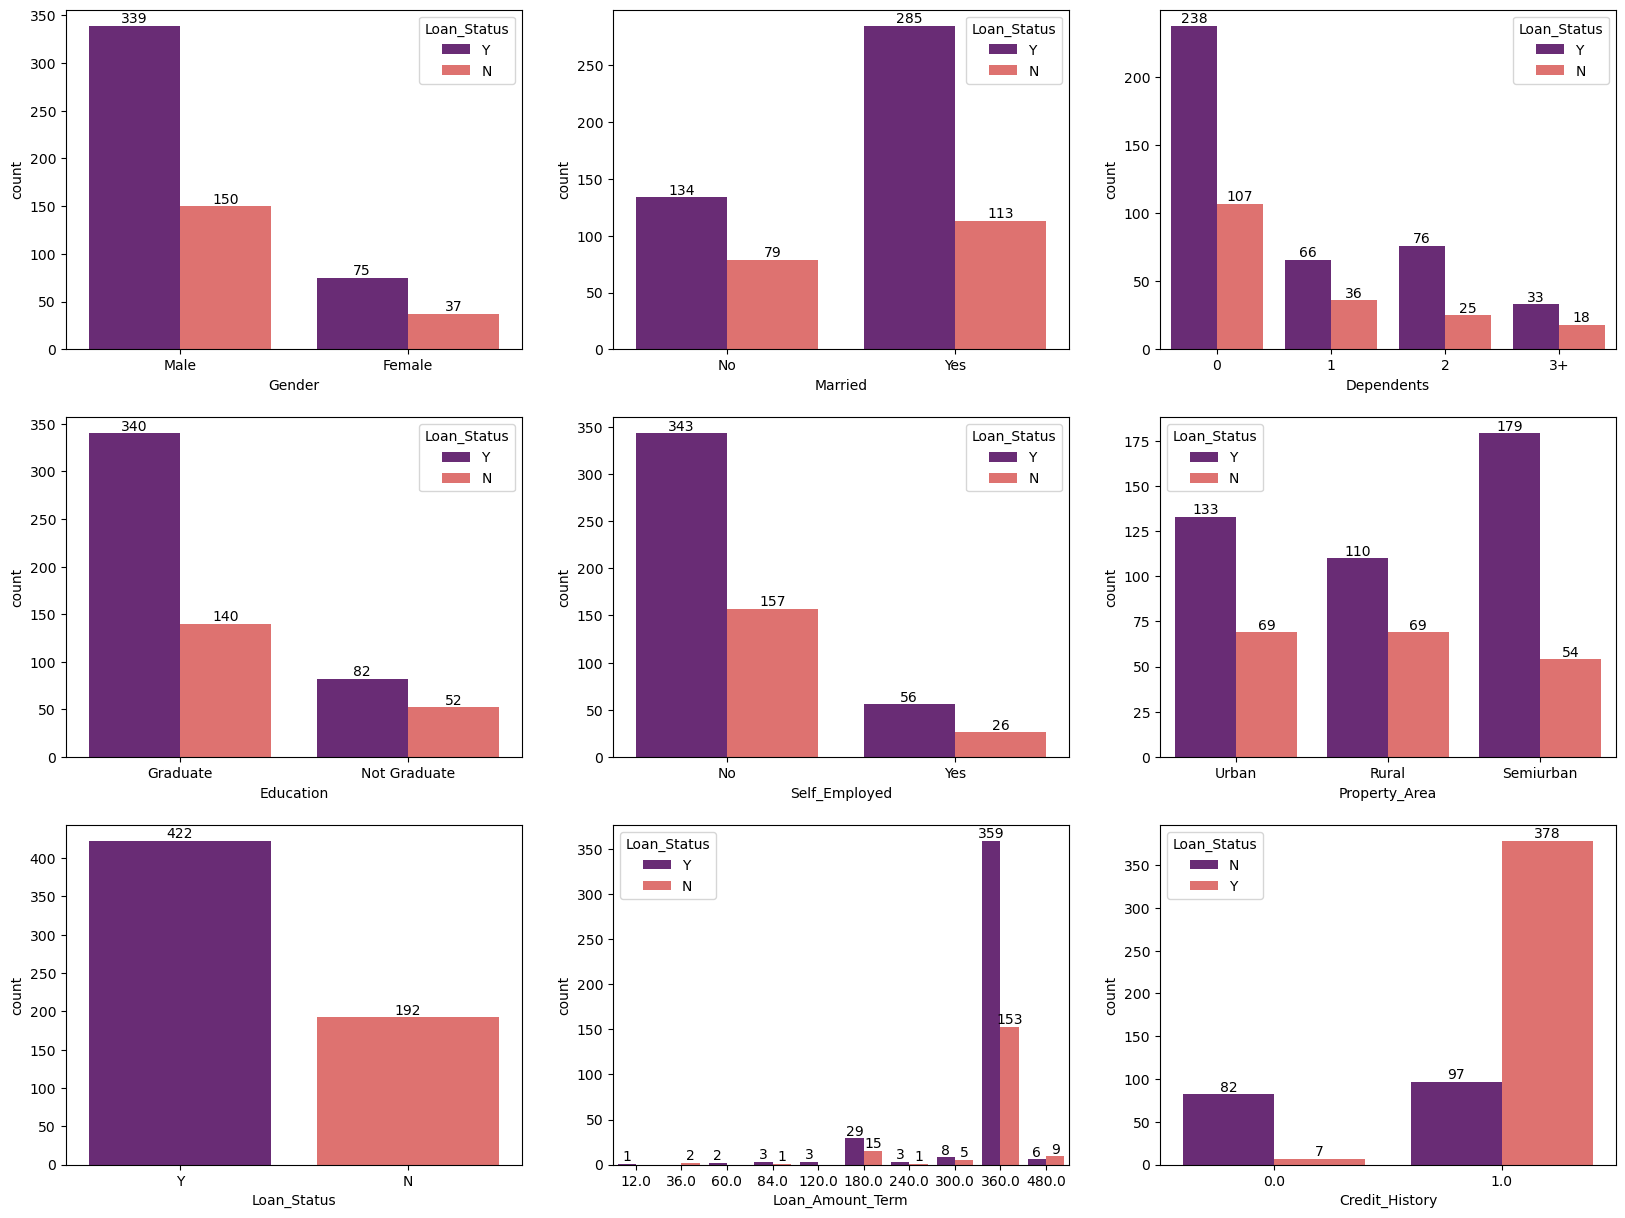

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
fig,axes = plt.subplots(3,3,figsize=(20,15))
for col, subplot in zip(categorical_cols,axes.flatten()):
    plot = sns.countplot(x=df[col],hue= df['Loan_Status'],ax=subplot,palette='magma')
    for container in plot.containers:
        plot.bar_label(container)
plt.show()

In [173]:
#NUMERICAL VARIABLES
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome','LoanAmount'] 
df[numerical_cols].describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount
count,614.000000,614.000000,592.000000
mean,5403.459283,1621.245798,146.412162
std,6109.041673,2926.248369,85.587325
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,100.000000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,168.000000
max,81000.000000,41667.000000,700.000000


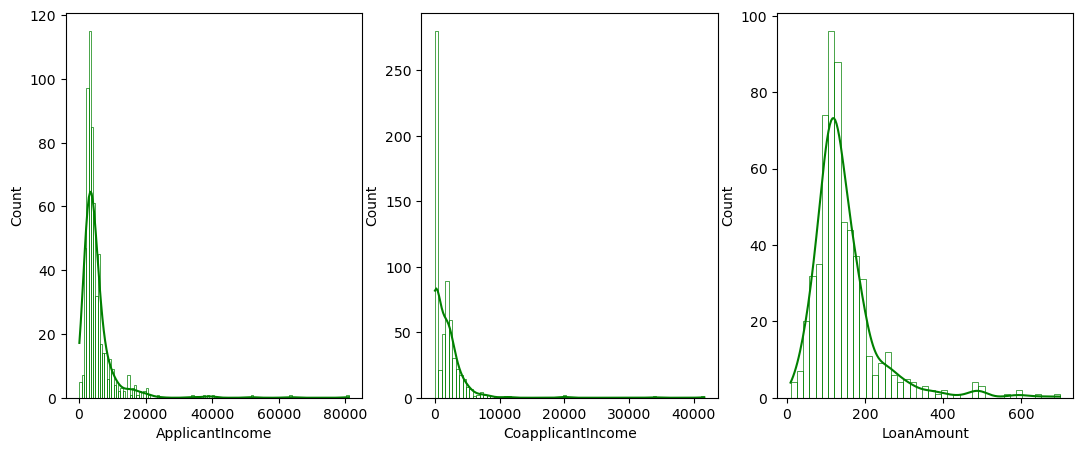

In [163]:
fig,axes = plt.subplots(ncols=3, figsize=(13,5))
for index, col in enumerate(numerical_cols):
    sns.histplot(data = df, x= col , kde= True, color= 'green',fill = False, ax = axes[index])
plt.show()

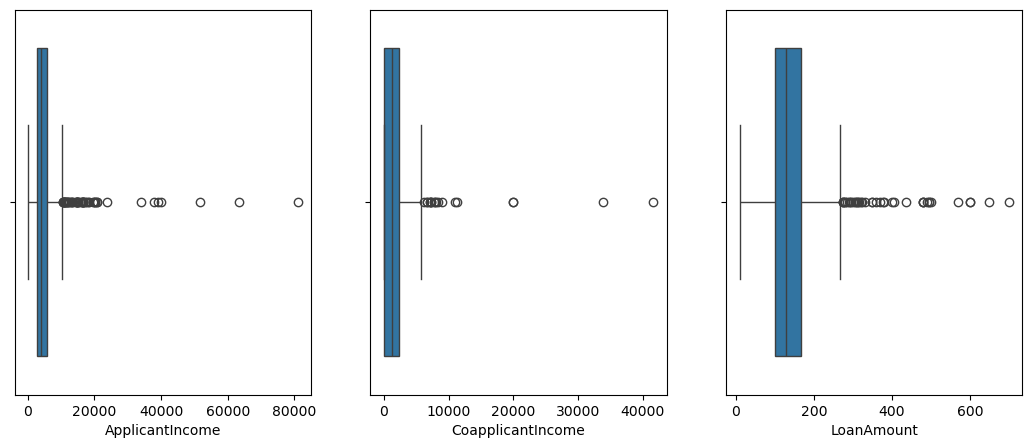

In [169]:
#VERIFYING OUTLIERS
fig,axes = plt.subplots(ncols=3, figsize=(13,5))
for index, col in enumerate(numerical_cols):
    sns.boxplot(data = df, x= col , ax = axes[index])
plt.show()

<Axes: >

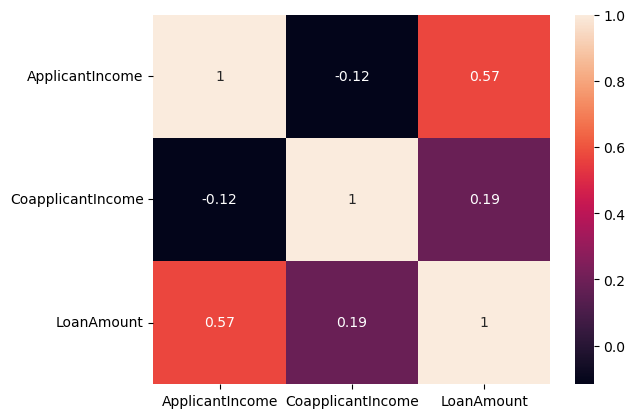

In [177]:
sns.heatmap(df[numerical_cols].corr(), annot = True)

In [183]:
#BIVARIATE ANALYSIS
df.groupby('Property_Area').Education.value_counts()

Property_Area  Education   
Rural          Graduate        131
               Not Graduate     48
Semiurban      Graduate        187
               Not Graduate     46
Urban          Graduate        162
               Not Graduate     40
Name: count, dtype: int64

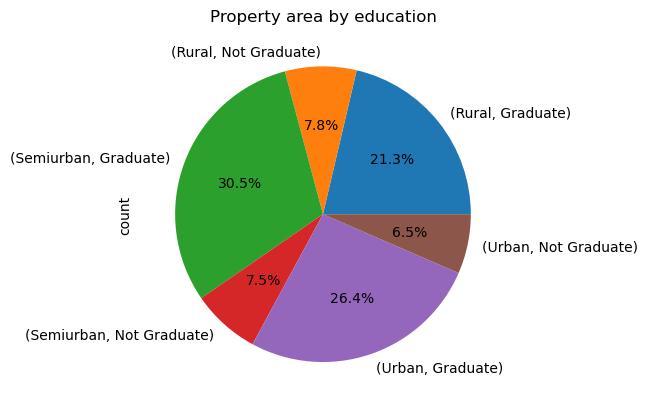

In [191]:
df.groupby('Property_Area').Education.value_counts().plot.pie(autopct = '%1.1f%%')
plt.title('Property area by education')
plt.show()

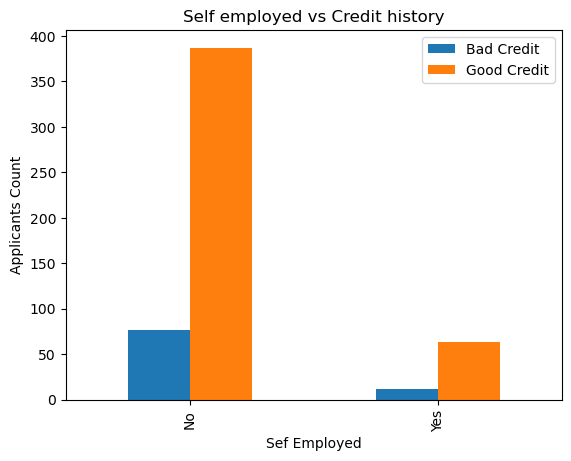

In [201]:
pd.crosstab(df['Self_Employed'],df['Credit_History']).plot.bar()
plt.title('Self employed vs Credit history')
plt.xlabel('Sef Employed')
plt.ylabel('Applicants Count')
plt.legend(['Bad Credit','Good Credit'])
plt.show()

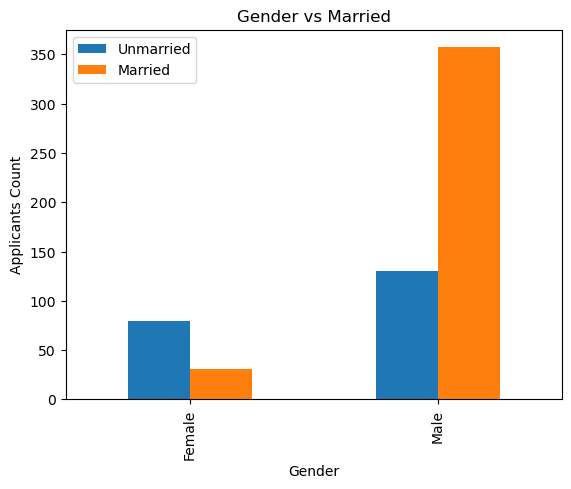

In [205]:
pd.crosstab(df['Gender'],df['Married']).plot.bar()
plt.title('Gender vs Married')
plt.xlabel('Gender')
plt.ylabel('Applicants Count')
plt.legend(['Unmarried','Married'])
plt.show()

In [207]:
df.groupby('Education')['Loan_Status'].count()

Education
Graduate        480
Not Graduate    134
Name: Loan_Status, dtype: int64

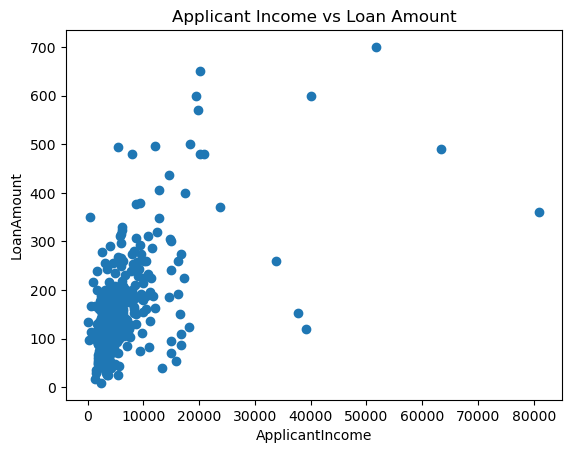

In [209]:
plt.scatter(df['ApplicantIncome'],df['LoanAmount'])
plt.xlabel('ApplicantIncome')
plt.ylabel('LoanAmount')
plt.title('Applicant Income vs Loan Amount')
plt.show()

<Axes: xlabel='Loan_Amount_Term'>

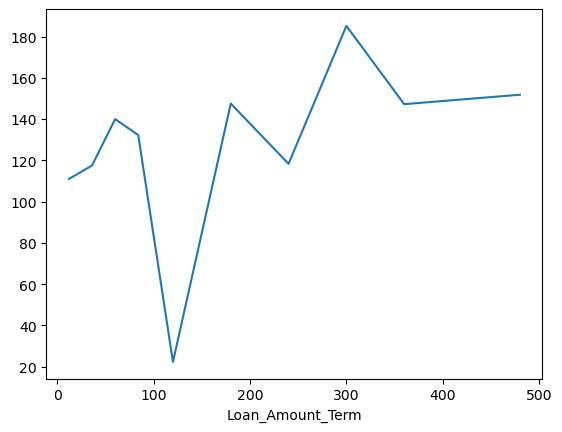

In [211]:
df.groupby('Loan_Amount_Term').LoanAmount.mean().plot()

<Axes: xlabel='Loan_Amount_Term', ylabel='LoanAmount'>

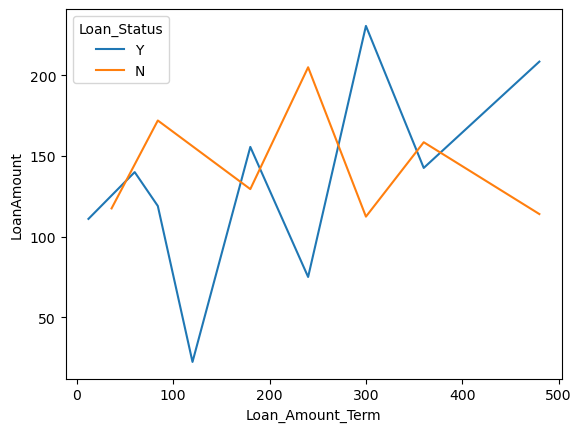

In [219]:
sns.lineplot(x= df['Loan_Amount_Term'],y = df['LoanAmount'], hue = df['Loan_Status'], errorbar= None)

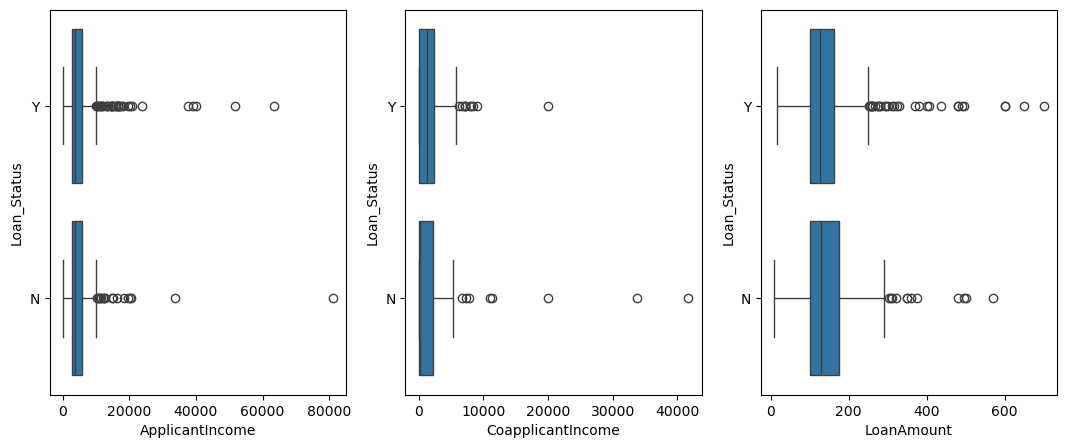

In [223]:
fig,axes = plt.subplots(ncols=3, figsize=(13,5))
for index, col in enumerate(numerical_cols):
    sns.boxplot(data = df, x= col ,y ='Loan_Status', ax = axes[index])
plt.show()

In [231]:
###Data Preprocessing

#Data Cleaning

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [256]:
null_count = df.isnull().sum()
null_cols = null_count[null_count >0 ].index.to_list()
print(null_cols)

['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [258]:
null_cols.remove('LoanAmount')

In [260]:
print(null_cols)

['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']


In [277]:
### IMPUTATION
def fillna_mode(col_name):
    df[col_name].fillna(df[col_name].mode()[0],inplace = True)

for col in null_cols:
    fillna_mode(col)

In [301]:
df['LoanAmount'].fillna(df['LoanAmount'].median())

0      128.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

In [303]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

<Axes: xlabel='LoanAmount'>

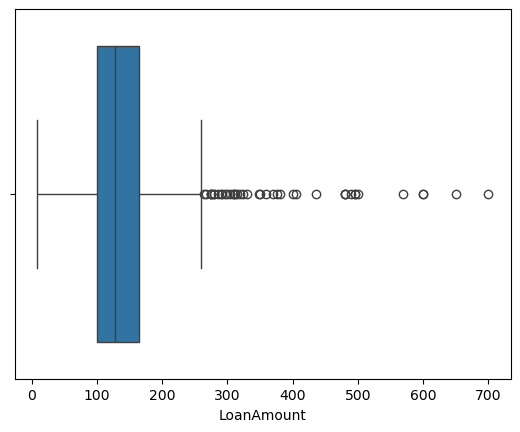

In [307]:
###Checking For Outliers
sns.boxplot(x=df['LoanAmount'])

In [319]:
###Remove Outliers
print(numerical_cols)

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']


In [325]:
n = numerical_cols.copy()

In [331]:
Q1 = df[n].quantile(0.25)
Q3 = df[n].quantile(0.75)
IQR= Q3 - Q1
df[n]= df[n][(df[n] >= (Q1-1.5 * IQR)) & (df[n] <= (Q3+1.5*IQR))]

<Axes: xlabel='LoanAmount'>

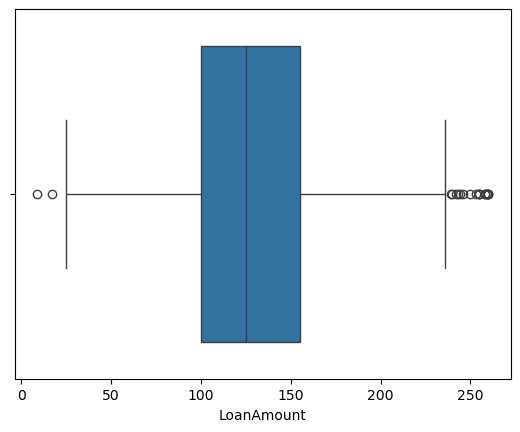

In [333]:
sns.boxplot(x=df['LoanAmount'])

In [335]:
###Square root transformation
def sqrt_transform(col):
    df[col]= df[col]**(1/2)

for col in numerical_cols:
    sqrt_transform(col)

<Axes: ylabel='Density'>

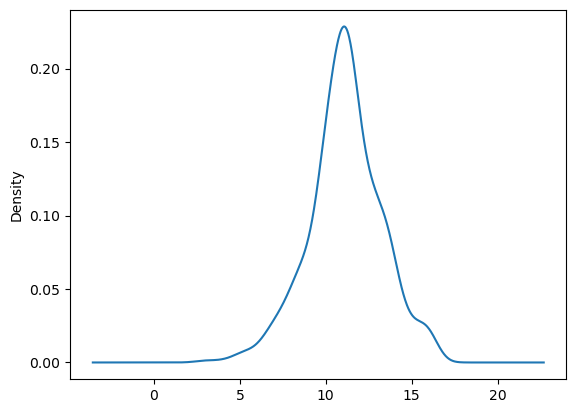

In [337]:
df['LoanAmount'].plot.kde()

array([<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>], dtype=object)

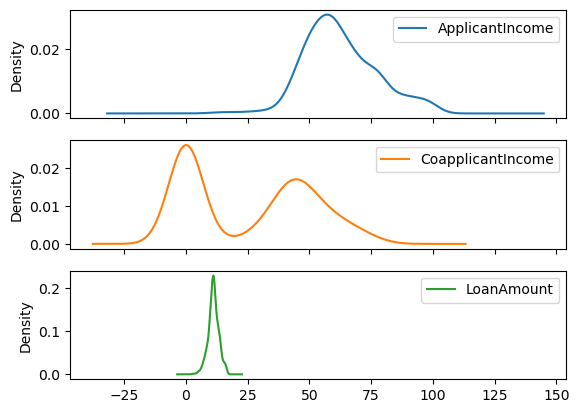

In [341]:
df[numerical_cols].plot(kind='kde', subplots = True )

In [343]:
df[numerical_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount
count,564.000000,596.000000,573.000000
mean,62.565293,25.637303,11.139134
std,14.514855,25.157895,2.100194
min,12.247449,0.000000,3.000000
25%,52.383109,0.000000,10.000000
50%,60.319876,32.109185,11.180340
75%,70.784769,46.615356,12.449900
max,100.692602,75.504967,16.124515


In [345]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,76.478755,0.000000,11.313708,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,67.697858,38.832976,11.313708,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,54.772256,0.000000,8.124038,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,50.823223,48.559242,10.954451,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,77.459667,0.000000,11.874342,360.0,1.0,Urban,Y


In [379]:
###Feature Selection
#Selecting Feature and Target
X = df.drop(['Loan_ID','Loan_Status'], axis= 1)
Y =df['Loan_Status']


In [381]:
X.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,76.478755,0.000000,11.313708,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,67.697858,38.832976,11.313708,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,54.772256,0.000000,8.124038,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,50.823223,48.559242,10.954451,360.0,1.0,Urban
4,Male,No,0,Graduate,No,77.459667,0.000000,11.874342,360.0,1.0,Urban


In [385]:
###Feature engineering
x_cat_cols = X.select_dtypes(include = 'O').columns

In [389]:
print(x_cat_cols)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')


In [391]:
x_cat_cols = list(x_cat_cols)+ ['Loan_Amount_Term']

In [393]:
print(x_cat_cols)

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Amount_Term']


In [397]:
###Handling Categorical Features
from sklearn.preprocessing import LabelEncoder
X[x_cat_cols]= X[x_cat_cols].apply(LabelEncoder().fit_transform)

In [399]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,76.478755,0.000000,11.313708,8,1.0,2
1,1,1,1,0,0,67.697858,38.832976,11.313708,8,1.0,0
2,1,1,0,0,1,54.772256,0.000000,8.124038,8,1.0,2
3,1,1,0,1,0,50.823223,48.559242,10.954451,8,1.0,2
4,1,0,0,0,0,77.459667,0.000000,11.874342,8,1.0,2


In [420]:
df['Credit_History'] = df['Credit_History'].astype(int)

In [424]:
X.dtypes

Gender                 int32
Married                int32
Dependents             int32
Education              int32
Self_Employed          int32
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term       int64
Credit_History       float64
Property_Area          int32
dtype: object

In [426]:
#Feature Scaling
print(numerical_cols)


['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']


In [430]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numerical_cols]= scaler.fit_transform(X[numerical_cols])

In [434]:
X.sample(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
49,0,0,0,0,0,0.046908,0.877585,0.410257,8,1.0,1
459,1,1,0,0,0,1.980795,-1.019912,0.719598,8,1.0,1
256,1,0,0,1,0,1.047050,-1.019912,-0.197930,8,0.0,0
8,1,1,2,0,0,0.050178,0.534147,0.868462,8,1.0,2
77,1,1,1,0,1,-2.133675,1.167032,-0.310264,8,1.0,2
